# Notebook de demo DIFMAP

Ce notebook montre un pipeline Python complet pour:

- charger un fichier UV/FITS;
- choisir une polarisation;
- connaitre les IFs disponibles et en selectionner un ou plusieurs;
- generer un plan UV;
- generer un radplot;
- construire une dirty map.

Chaque cellule ouvre sa propre `DifmapSession()` pour rester robuste pendant la demo.

In [ ]:
from difmap_wrapper import DifmapSession

DATA_PATH = "tests/test_data/0003-066_X.SPLIT.1"
REQUESTED_POL = "RR"
REQUESTED_IFS = (1, 2)

# On crée l'instance sans le bloc 'with'
session = DifmapSession()

# On charge les données et on sélectionne ce qui nous intéresse
session.observe(DATA_PATH)
selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)

DATA_PATH     : tests/test_data/0003-066_X.SPLIT.1
POL demandee : RR
IFs demandes : (1, 2)


In [ ]:
# Plus besoin de recharger, l'objet session se souvient de l'état
data = session.obs.get_data()
print(f"Nombre de visibilites : {len(data['u'])}")
print(f"Amplitude moyenne (Jy): {data['amp'].mean():.4f}")

## 1. Charger le fichier et inspecter son contenu

In [ ]:
import matplotlib.pyplot as plt

session.vis.uvplot(
    figsize=(7, 7),
    color="steelblue",
    s=3,
    alpha=0.35,
    title=f"UV plane - {session.obs.source}"
)
plt.show()

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

## 2. Selectionner une polarisation et un ou plusieurs IFs

In [6]:
with DifmapSession() as session:
    session.observe(str(DATA_PATH))
    selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)
    data = session.obs.get_data()

    print(f"Polarisation retenue  : {selected_pol}")
    print(f"IFs demandes          : {fmt_if_range(REQUESTED_IFS)}")
    print(f"IFs effectivement lus : {unique_ifs(data)}")
    print(f"Nombre de visibilites : {len(data['u'])}")
    print(f"Amplitude moyenne (Jy): {data['amp'].mean():.4f}")

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

## 3. Generer le plan UV

Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

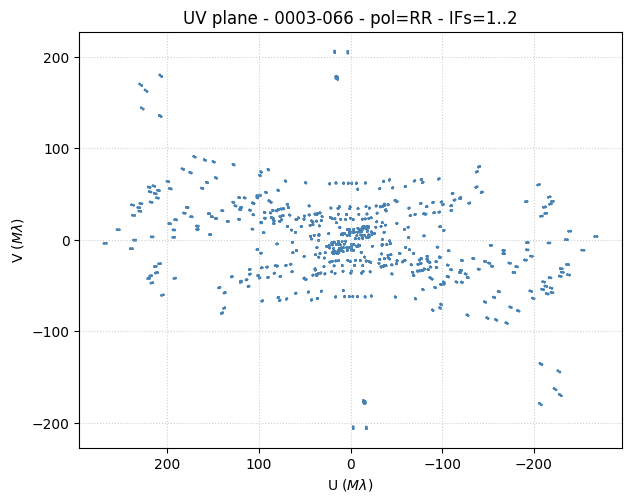

In [7]:
with DifmapSession() as session:
    session.observe(str(DATA_PATH))
    selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)
    session.vis.uvplot(
        figsize=(7, 7),
        color="steelblue",
        s=3,
        alpha=0.35,
        title=f"UV plane - {session.obs.source} - pol={selected_pol} - IFs={fmt_if_range(REQUESTED_IFS)}"
    )
    plt.show()

## 4. Generer le radplot

In [ ]:
with DifmapSession() as session:
    session.observe(str(DATA_PATH))
    selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)
    session.vis.radplot(
        figsize=(9, 5),
        color="black",
        s=3,
        alpha=0.35,
        title=f"Radplot - {session.obs.source} - pol={selected_pol} - IFs={fmt_if_range(REQUESTED_IFS)}"
    )
    plt.show()

## 5. Construire une dirty map

In [ ]:
with DifmapSession() as session:
    session.observe(str(DATA_PATH))
    selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)

    session.imager.uvweight(bin_size=2.0, err_power=0.0)
    session.imager.mapsize(MAP_SIZE, CELL_SIZE_MAS)
    session.imager.invert()

    dirty = session.imager.get_map_package(cellsize=CELL_SIZE_MAS)
    print("Dirty map info:")
    print(dirty["info"])

    session.vis.mapplot(
        dirty,
        title=f"Dirty map - {session.obs.source} - pol={selected_pol} - IFs={fmt_if_range(REQUESTED_IFS)}",
        cmap="inferno"
    )

## 6. Variante utile pour la demo

Pour montrer plusieurs cas rapidement, il suffit de changer dans la cellule de configuration:

- `DATA_PATH` pour pointer vers un autre fichier;
- `REQUESTED_POL` pour changer de polarisation;
- `REQUESTED_IFS` pour passer de `(1, 2)` a `(1, 0)` ou `(3, 4)`;
- `MAP_SIZE` et `CELL_SIZE_MAS` pour ajuster la dirty map.

Le notebook reste volontairement simple pour etre relancable en direct pendant la presentation.